In [15]:
import numpy as np
import pandas as pd
from sklearn . datasets import fetch_openml
from sklearn . model_selection import train_test_split
from sklearn . linear_model import LogisticRegression
from sklearn . multiclass import OneVsRestClassifier
from sklearn . multioutput import ClassifierChain
from sklearn . metrics import accuracy_score
from sklearn . metrics import hamming_loss
from sklearn . metrics import jaccard_score
X, Y = fetch_openml("emotions", version=4, return_X_y=True)
Y = (Y == "TRUE").astype(int)
X_train , X_test , Y_train , Y_test = train_test_split(
X, Y, test_size=0.3, random_state=42
)

# Task 1

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns
def plot_correlation_matrix(m):
    plt.figure(figsize=(20, 15))
    sns.heatmap(m,
                annot=True,
                cmap='RdBu_r',  # Red-Blue is often more intuitive for +/- correlations
                center=0,  # Ensure 0 is the neutral color
                linewidths=.1,
                cbar_kws={"shrink": .8},
                vmin=-1, vmax=1)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

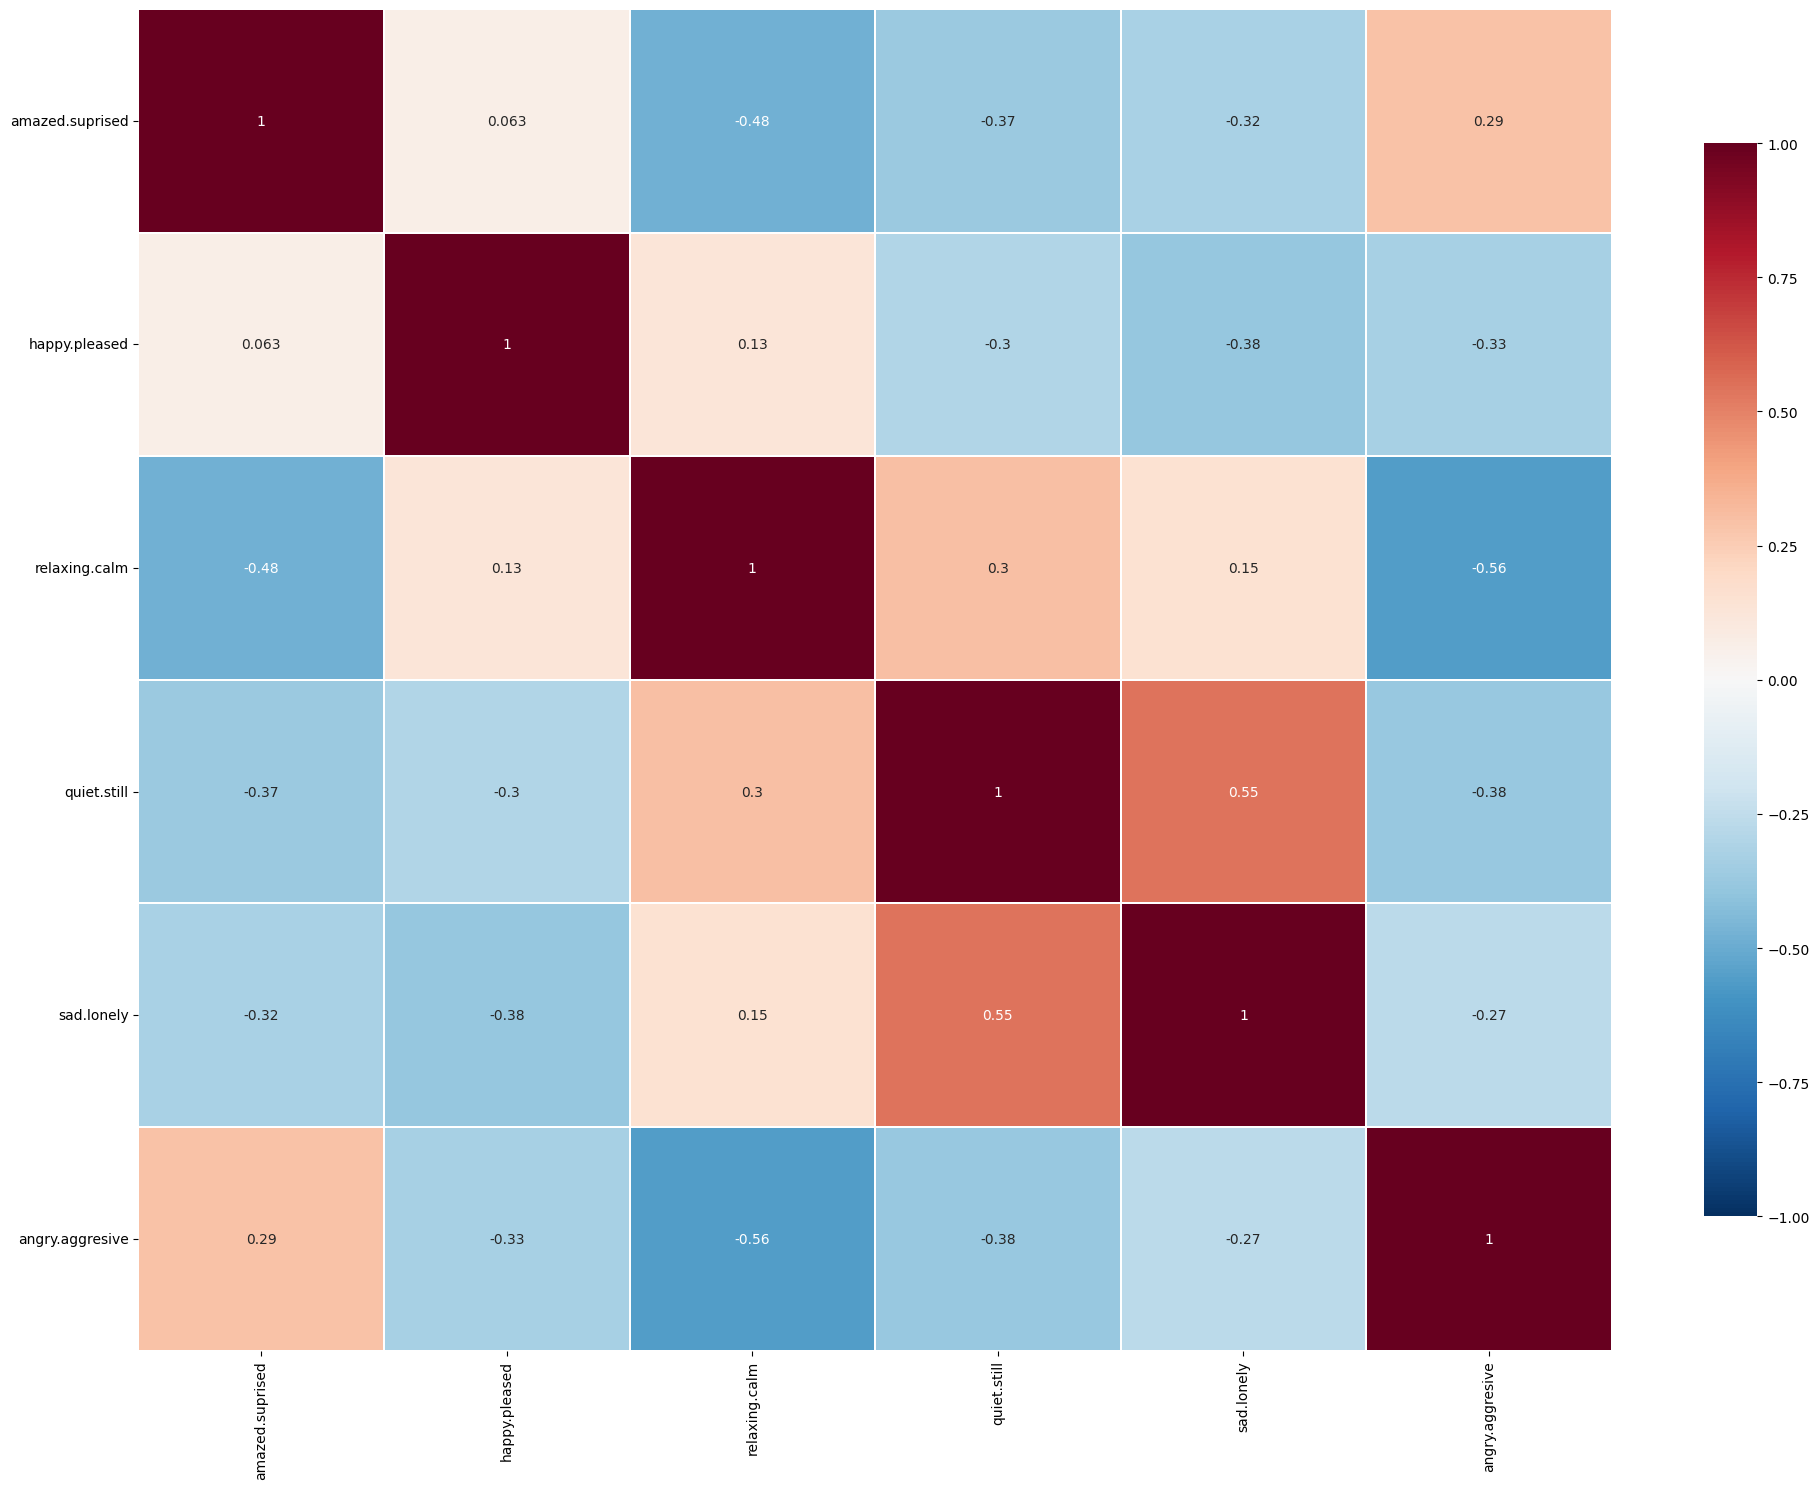

In [3]:
corr_labels=Y.corr()
plot_correlation_matrix(corr_labels)

strongest correlation between angry.agressive and relaxing.calm (negative correlation), other strong correlations are also negative. The only strong positve is sad.lonely and quiet.still .
Therefore it cannot be stated that the labels are independent, which means methods such as Binary Relevance may not be adequate.

In [4]:
for i in range(Y.shape[1]):
    print(f"Label {Y.columns[i]} is present in {np.sum(Y.iloc[:,i])} out of {Y.shape[0]} observations")

Label amazed.suprised is present in 173 out of 593 observations
Label happy.pleased is present in 166 out of 593 observations
Label relaxing.calm is present in 264 out of 593 observations
Label quiet.still is present in 148 out of 593 observations
Label sad.lonely is present in 168 out of 593 observations
Label angry.aggresive is present in 189 out of 593 observations


(array([178.,   0.,   0., 315.,   0., 100.]),
 array([1.        , 1.33333333, 1.66666667, 2.        , 2.33333333,
        2.66666667, 3.        ]),
 <BarContainer object of 6 artists>)

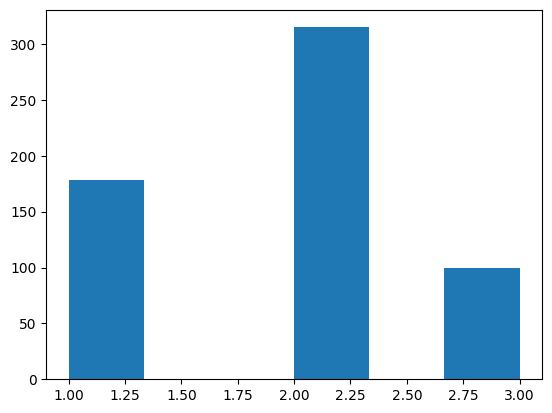

In [8]:
active_ct=np.zeros(Y.shape[0])
for i in range(Y.shape[0]):
    active_ct[i]=np.sum(Y.iloc[i,:])
plt.hist(active_ct, bins=6)

# TASK 2

In [9]:
def evaluate(name, Y_true, Y_pred):
    subset_acc=accuracy_score(Y_true, Y_pred)
    hamming=1-hamming_loss(Y_true, Y_pred)
    jacc = jaccard_score(Y_true, Y_pred, average="samples")
    print(
    f"{name:5}␣−>␣"
    f"Subset␣accuracy:␣{subset_acc:.3f},␣"
    f"Hamming␣score:␣{hamming:.3f},␣"
    f"Jaccard␣score:␣{jacc:.3f}"
    )

In [10]:
base_estimator=LogisticRegression(solver="liblinear")

In [11]:
br = OneVsRestClassifier(base_estimator)
br.fit(X_train, Y_train)
y_pred=br.predict(X_test)
evaluate("BR",Y_test,y_pred)

BR   ␣−>␣Subset␣accuracy:␣0.270,␣Hamming␣score:␣0.795,␣Jaccard␣score:␣0.493


In [12]:
rng = np.random.default_rng(seed=42)
unique_orders = []

while len(unique_orders) < 10:
    new_order = list(rng.permutation(6))
    if new_order not in unique_orders:
        unique_orders.append(new_order)
results = []

print("Evaluating 10 Random Chain Orders:\n")
print(f"{'Chain Order':<25} | {'Jaccard Score (Higher=Better)':<30} | {'Hamming Loss (Lower=Better)':<25}")
print("-" * 88)

for i, order in enumerate(unique_orders):
    chain = ClassifierChain(base_estimator, order=order, random_state=42)
    chain.fit(X_train, Y_train)
    Y_pred = chain.predict(X_test)
    jaccard = jaccard_score(Y_test, Y_pred, average='samples')
    h_loss = hamming_loss(Y_test, Y_pred)

    results.append({
        'order': order,
        'jaccard': jaccard,
        'hamming': h_loss,
        'model': chain
    })

    print(f"{str(order):<25} | {jaccard:<30.4f} | {h_loss:<25.4f}")

# 5. Identify the best performing order
best_result = max(results, key=lambda x: x['jaccard'])

print("\n" + "="*50)
print(f"🏆 BEST ORDER: {best_result['order']}")
print(f"Best Jaccard Score: {best_result['jaccard']:.4f}")
print("="*50)

Evaluating 10 Random Chain Orders:

Chain Order               | Jaccard Score (Higher=Better)  | Hamming Loss (Lower=Better)
----------------------------------------------------------------------------------------
[np.int64(3), np.int64(2), np.int64(5), np.int64(4), np.int64(1), np.int64(0)] | 0.5524                         | 0.2135                   
[np.int64(2), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(5)] | 0.5426                         | 0.2144                   
[np.int64(5), np.int64(4), np.int64(2), np.int64(3), np.int64(0), np.int64(1)] | 0.5838                         | 0.1948                   
[np.int64(4), np.int64(0), np.int64(2), np.int64(3), np.int64(5), np.int64(1)] | 0.5440                         | 0.2116                   
[np.int64(5), np.int64(0), np.int64(4), np.int64(2), np.int64(3), np.int64(1)] | 0.5754                         | 0.2013                   
[np.int64(1), np.int64(0), np.int64(5), np.int64(4), np.int64(3), np.int64(2)] | 0.539

In [14]:
M = 20
unique_orders = []
while len(unique_orders) < M:
    new_order = list(rng.permutation(6))
    if new_order not in unique_orders:
        unique_orders.append(new_order)


all_chain_preds = np.zeros((M, X_test.shape[0], Y_test.shape[1]))

for m, order in enumerate(unique_orders):
    chain = ClassifierChain(base_estimator, order=order, random_state=42)
    chain.fit(X_train, Y_train)

    all_chain_preds[m] = chain.predict(X_test)


voting_average = np.mean(all_chain_preds, axis=0)

Y_pred_ECC = (voting_average >= 0.5).astype(int)

ecc_jaccard = jaccard_score(Y_test, Y_pred_ECC, average='samples')
ecc_hamming = hamming_loss(Y_test, Y_pred_ECC)

print(f"Ensemble Size (M): {M}")
print(f"ECC Jaccard Score : {ecc_jaccard:.4f}")
print(f"ECC Hamming Loss :   {ecc_hamming:.4f}")

Ensemble Size (M): 20
ECC Jaccard Score : 0.5861
ECC Hamming Loss :   0.1901


# Task 3

In [ ]:
class CCC:
    def __init__(self,base_estimator,max_iter):
        self.base_estimator = base_estimator
        self.max_iter = max_iter
        self.classifiers=[]
    @staticmethod
    def random_initialization(n_cols):
        return (np.random.uniform(0,1,n_cols)>0.5).astype(int)
    @staticmethod
    def all_zero_initialization(n_cols):
        return np.zeros(n_cols).astype(int)
    def br_initialization(self,n_cols,x):
        y=np.zeros(n_cols)
        for i in range(n_cols):
            y[i]=self.classifiers[i].predict(x)
        return y
    def fit_ccc(self,X,y):
        for k in y.columns:
            y_k = y[k].copy()
            Y_minus_k = y.drop(columns=[k])
            X_augmented = pd.concat([X, Y_minus_k], axis=1)
            cl=self.base_estimator.fit(X_augmented,y_k)
            self.classifiers.append(cl)
    def predict_cc(self,X,initialization='random'):
        n_cols=len(self.classifiers)
        if initialization == 'random':
            y=CCC.random_initialization(n_cols)
        elif initialization == 'all_zeros':
            y=CCC.all_zero_initialization(n_cols)
        elif initialization == 'br':
            y=self.br_initialization(n_cols,X)
        else:
            raise ValueError("Initialization must be 'random' or 'all_zeros' or 'br'")
        sigma = np.random.permutation(n_cols)
        converged = False
        for iteration in range(self.max_iter):
            y_old = y.copy()

            for j in sigma:
                Y_minus_k = y_old.drop(columns=[X.columns[j]])
                X_augmented = pd.concat([X, Y_minus_k], axis=1)
                y[j] = self.classifiers[j].predict(X_augmented)


            if np.array_equal(y, y_old):
                converged = True
                print(f"Converged after {iteration + 1} iterations.")
                break

        if not converged:
            print(f"Warning: Convergence not achieved within {self.max_iter} iterations. Returning last iterate.")

        return y



In [17]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

class CCC:
    def __init__(self, base_estimator, max_iter=20):
        self.base_estimator = base_estimator
        self.max_iter = max_iter
        self.classifiers = {}  # Using a dict mapped to column names for safety
        self.label_names = []

    @staticmethod
    def random_initialization(n_cols):
        return (np.random.uniform(0, 1, n_cols) > 0.5).astype(int)

    @staticmethod
    def all_zero_initialization(n_cols):
        return np.zeros(n_cols, dtype=int)

    def fit_ccc(self, X, y):
        self.label_names = list(y.columns)

        for k in self.label_names:
            y_k = y[k].copy()
            # Drop current label to get Y_-k
            y_minus_k = y.drop(columns=[k])
            # Concatenate X and Y_-k
            X_augmented = pd.concat([X, y_minus_k], axis=1)

            # CRITICAL: Clone the estimator so they don't overwrite each other
            cl = clone(self.base_estimator)
            cl.fit(X_augmented, y_k)
            self.classifiers[k] = cl

    def predict_cc(self, X_single, initialization='random', br_predictions=None):
        """
        Predicts labels for a SINGLE observation (Pandas Series or 1-row DataFrame)
        """
        # Ensure X_single is a DataFrame row with correct columns
        if isinstance(X_single, pd.Series):
            X_single = X_single.to_frame().T

        n_labels = len(self.label_names)

        # 1. Initialization
        if initialization == 'random':
            y_arr = CCC.random_initialization(n_labels)
        elif initialization == 'all_zeros':
            y_arr = CCC.all_zero_initialization(n_labels)
        elif initialization == 'br':
            if br_predictions is not None:
                y_arr = np.array(br_predictions)
            else:
                raise ValueError("For 'br' initialization, pass initial BR predictions via `br_predictions` parameter.")
        else:
            raise ValueError("Initialization must be 'random', 'all_zeros', or 'br'")

        # Convert initial array to a Series mapped to label names for easy manipulation
        y_current = pd.Series(y_arr, index=self.label_names)

        # 2. Permutation
        sigma = np.random.permutation(self.label_names)
        converged = False

        # 3. Cyclic updates
        for iteration in range(self.max_iter):
            y_old = y_current.copy()

            for k in sigma:
                # Get all labels except the current one 'k'
                y_minus_k = y_current.drop(labels=[k]).to_frame().T
                # Reset index so it aligns perfectly with X_single row index
                y_minus_k.index = X_single.index

                # Reconstruct X_augmented exactly how it looked during training
                X_augmented = pd.concat([X_single, y_minus_k], axis=1)

                # Ensure column ordering matches training expectations
                expected_cols = list(X_single.columns) + [col for col in self.label_names if col != k]
                X_augmented = X_augmented[expected_cols]

                # Predict
                y_current[k] = self.classifiers[k].predict(X_augmented)[0]

            # Check if entire label vector stabilized
            if np.array_equal(y_current.values, y_old.values):
                converged = True
                print(f"Converged after {iteration + 1} iterations.")
                break

        if not converged:
            print(f"Warning: Convergence not achieved within {self.max_iter} iterations. Returning last iterate.")

        return y_current

In [18]:

base_lr = LogisticRegression(solver="liblinear")
br_model = OneVsRestClassifier(base_lr)
br_model.fit(X_train, Y_train)

Y_test_br_preds = pd.DataFrame(br_model.predict(X_test), columns=Y_train.columns, index=X_test.index)

def predict_batch_ccc(ccc_instance, X_matrix, initialization='random', br_preds_df=None):

    predictions = []
    iterations_taken = []

    import os, sys
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

    try:
        for idx in range(len(X_matrix)):
            row = X_matrix.iloc[[idx]]
            br_init_row = br_preds_df.iloc[idx].values if br_preds_df is not None else None

            sys.stdout = old_stdout

            y_curr = ccc_instance.random_initialization(len(ccc_instance.label_names))
            if initialization == 'all_zeros': y_curr = ccc_instance.all_zero_initialization(len(ccc_instance.label_names))
            elif initialization == 'br': y_curr = br_init_row

            y_current = pd.Series(y_curr, index=ccc_instance.label_names)
            sigma = np.random.permutation(ccc_instance.label_names)
            converged_at = ccc_instance.max_iter

            for iteration in range(ccc_instance.max_iter):
                y_old = y_current.copy()
                for k in sigma:
                    y_minus_k = y_current.drop(labels=[k]).to_frame().T
                    y_minus_k.index = row.index
                    X_augmented = pd.concat([row, y_minus_k], axis=1)
                    expected_cols = list(row.columns) + [col for col in ccc_instance.label_names if col != k]
                    X_augmented = X_augmented[expected_cols]
                    y_current[k] = ccc_instance.classifiers[k].predict(X_augmented)[0]

                if np.array_equal(y_current.values, y_old.values):
                    converged_at = iteration + 1
                    break

            predictions.append(y_current.copy())
            iterations_taken.append(converged_at)
            sys.stdout = open(os.devnull, 'w') # silence back
    finally:
        sys.stdout = old_stdout

    return pd.DataFrame(predictions), np.mean(iterations_taken)



ccc = CCC(base_estimator=LogisticRegression(solver="liblinear"), max_iter=20)
ccc.fit_ccc(X_train, Y_train)

print("--- Starting CCC Experiments ---\n")

preds_zero, avg_iter_zero = predict_batch_ccc(ccc, X_test, initialization='all_zeros')
print(f"[All-Zero Init] Average iterations to stabilize: {avg_iter_zero:.2f}")
evaluate("CCC (Zeros)", Y_test, preds_zero)
print("-" * 60)

preds_br_init, avg_iter_br = predict_batch_ccc(ccc, X_test, initialization='br', br_preds_df=Y_test_br_preds)
print(f"[BR Init] Average iterations to stabilize: {avg_iter_br:.2f}")
evaluate("CCC (BR-Init)", Y_test, preds_br_init)
print("-" * 60)

print("Running 3 separate random initializations to check stability...")
for i in range(3):
    preds_rand, avg_iter_rand = predict_batch_ccc(ccc, X_test, initialization='random')
    print(f" > Random Run #{i+1} | Avg Iterations: {avg_iter_rand:.2f}")
    evaluate(f"CCC (Rand #{i+1})", Y_test, preds_rand)
print("-" * 60)

print("Running variations with different update order permutations...")
for i in range(3):
    preds_perm, avg_iter_perm = predict_batch_ccc(ccc, X_test, initialization='all_zeros')
    print(f" > Permutation Run #{i+1} | Avg Iterations: {avg_iter_perm:.2f}")
    evaluate(f"CCC (Perm #{i+1})", Y_test, preds_perm)

--- Starting CCC Experiments ---

[All-Zero Init] Average iterations to stabilize: 2.18
CCC (Zeros)␣−>␣Subset␣accuracy:␣0.258,␣Hamming␣score:␣0.741,␣Jaccard␣score:␣0.465
------------------------------------------------------------
[BR Init] Average iterations to stabilize: 1.49
CCC (BR-Init)␣−>␣Subset␣accuracy:␣0.331,␣Hamming␣score:␣0.792,␣Jaccard␣score:␣0.572
------------------------------------------------------------
Running 3 separate random initializations to check stability...
 > Random Run #1 | Avg Iterations: 2.54
CCC (Rand #1)␣−>␣Subset␣accuracy:␣0.225,␣Hamming␣score:␣0.726,␣Jaccard␣score:␣0.438
 > Random Run #2 | Avg Iterations: 2.48
CCC (Rand #2)␣−>␣Subset␣accuracy:␣0.281,␣Hamming␣score:␣0.756,␣Jaccard␣score:␣0.499
 > Random Run #3 | Avg Iterations: 2.52
CCC (Rand #3)␣−>␣Subset␣accuracy:␣0.281,␣Hamming␣score:␣0.772,␣Jaccard␣score:␣0.517
------------------------------------------------------------
Running variations with different update order permutations...
 > Permutation R

## 1. Binary Relevance: Label-Dependence Assumption

Binary Relevance assumes complete **label conditional independence**, conditioned by X. It treats each label as an isolated binary classification task, assuming the presence of one label carries zero information about any other.



## 2. Classifier Chains (CC): Influence of Label Ordering

The order matters due to **error propagation**, as each classifier uses the predicted outputs of all preceding labels in the chain as input features. A mistake made early in the chain cascades downward, negatively biasing all subsequent predictions.



## 3. Why ECC is More Stable than a Single CC

An Ensemble of Classifier Chains (ECC) trains multiple chains using different random label orderings and data subsamples, then aggregates their predictions via voting. This ensemble approach averages out the negative impacts of individual "bad" orderings and reduces variance caused by error propagation.



## 4.  Why is subset accuracy usually much smaller than Hamming score

Subset accuracy is a strict metric that requires the entire predicted label vector to be a **perfect match** with the ground truth, scoring 0 for even a single mistake. Hamming score evaluates success on a per-label basis, rewarding the model fractionally for every individual correct label prediction.



## 5. Why is Jaccard score often more informative than Hamming score when active labels are rare?

When positive labels are rare, a model can score artificially high on Hamming metric simply by guessing all zeros and correctly matching the abundant negative labels. The Jaccard score is more informative because it entirely ignores true negatives, focusing exclusively on the overlap of actual and predicted positive labels.



## 6. CCC and Self-Consistent Label Vectors

The Conditional Classifier Chain (CCC) iteratively updates each label based on the current predicted states of all other labels. This process can be viewed as a search for a self-consistent vector because the algorithm runs until it reaches a stable state where no label changes its value given the surrounding context.



## 7. CCC: Coherent Joint Model vs. Conditional Collection

CCC defines **only a collection of conditional models**, as each classifier maximizes its own local probability $P(Y_j \mid Y_{\setminus j}, X)$ without a global normalizing constant to bind them. This distinction is critical because without a coherent joint distribution, the probabilities can be mathematically inconsistent, forcing reliance on heuristic approximations (like Gibbs sampling) rather than exact global inference.